In [ ]:
# ==============================================================================
# SCRIPT: Sentiment Analysis Pipeline (FINAL VERSION)
# ==============================================================================

import re
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from transformers import pipeline

# --------------------------------
# 1. SETUP AND CONFIGURATION
# --------------------------------

# --- File Names ---
INPUT_FILE = 'Data1-clean.csv'
CLEANED_FILE = 'cleaning.csv'
OUTPUT_FILE = 'final_sentiment_categorized.csv'

# --- Normalization Dictionary ---
normalization_dict = {
    # (The dictionary is long, so it's omitted here for brevity, but it is included in the full code block below)
    'yg': 'yang', 'dgn': 'dengan', 'utk': 'untuk', 'kpd': 'kepada',
    'dr': 'dari', 'karna': 'karena', 'krn': 'karena', 'bkn': 'bukan',
    'jg': 'juga', 'sdh': 'sudah', 'udh': 'sudah', 'udah': 'sudah',
    'blm': 'belum', 'thn': 'tahun', 'tgl': 'tanggal', 'dll': 'dan lain lain',
    'dsb': 'dan sebagainya', 'sbg': 'sebagai', 'tdk': 'tidak',
    'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'jgn': 'jangan',
    'bnyk': 'banyak', 'dpt': 'dapat', 'aja': 'saja', 'sja': 'saja',
    'trus': 'terus', 'trs': 'terus', 'gw': 'saya', 'gue': 'saya', 'ane': 'saya', 
    'sy': 'saya', 'lu': 'kamu', 'loe': 'kamu', 'klen': 'kalian', 'bgt': 'banget', 
    'mantul': 'mantap', 'keren': 'bagus', 'oke': 'baik', 'bagus': 'baik', 
    'mantap': 'baik', 'top': 'baik', 'recommended': 'bagus', 'gokil': 'luar biasa', 
    'amazing': 'luar biasa', 'wow': 'luar biasa', 'perfect': 'sempurna', 
    'excellent': 'sangat baik', 'jelek': 'buruk', 'parah': 'buruk', 'gaje': 'buruk', 
    'zonk': 'buruk', 'disappointing': 'mengecewakan', 'terrible': 'buruk', 
    'awful': 'buruk', 'hate': 'benci', 'sucks': 'buruk', 'worst': 'terburuk',
    'rubbish': 'sampah', 'useless': 'tidak berguna', 'waste': 'buruk', 'mulyono': 'buruk',
    'cuman': 'cuma', 'emang': 'memang', 'kalo': 'kalau', 'klo': 'kalau', 'pake': 'pakai', 
    'jd': 'jadi', 'lg': 'lagi', 'emg': 'memang', 'kyk': 'seperti', 'kek': 'seperti', 
    'hny': 'hanya', 'knp': 'kenapa', 'gmn': 'bagaimana', 'kpn': 'kapan', 'brp': 'berapa',
    'sblm': 'sebelum', 'stlh': 'setelah',
}

# --------------------------------
# 2. HELPER FUNCTIONS
# --------------------------------

def clean_text_improved(text, stemmer, custom_stopwords):
    """Improved text cleaning function that preserves sentiment"""
    if pd.isna(text):
        return ''
    
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[!]{2,}', ' sangat ', text)
    text = re.sub(r'[?]{2,}', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    tokens = [normalization_dict.get(tok, tok) for tok in tokens]
    tokens = [tok for tok in tokens if len(tok) >= 2 or tok in ['ga', 'ng']]
    tokens = [tok for tok in tokens if tok not in custom_stopwords]
    
    sentiment_preserve = {'bagus', 'buruk', 'jelek', 'baik', 'suka', 'benci', 'senang', 'sedih'}
    tokens = [tok if tok in sentiment_preserve else stemmer.stem(tok) for tok in tokens]
    
    return ' '.join(tokens)

def analyze_sentiment_improved(texts, sentiment_analyzer, batch_size=16):
    """Improved sentiment analysis with confidence handling"""
    results = []
    total_texts = len(texts)
    for i in range(0, total_texts, batch_size):
        batch = texts[i:i+batch_size]
        
        try:
            # The pipeline is much faster when processing a batch of texts
            batch_results_raw = sentiment_analyzer(batch)
            
            for scores in batch_results_raw:
                best_pred = max(scores, key=lambda x: x['score'])
                results.append({
                    'label': best_pred['label'],
                    'score': best_pred['score'],
                    'all_scores': scores
                })
        except Exception as e:
            print(f"Error processing a batch: {e}. Processing one-by-one as fallback.")
            # Fallback to one-by-one processing for the failed batch
            for text in batch:
                try:
                    scores = sentiment_analyzer(text)[0] # sentiment_analyzer returns a list of lists for single string
                    best_pred = max(scores, key=lambda x: x['score'])
                    results.append({'label': best_pred['label'], 'score': best_pred['score'], 'all_scores': scores})
                except Exception as e_single:
                    print(f"Error processing single text: '{text[:50]}...'. Error: {e_single}")
                    results.append({'label': 'NEUTRAL', 'score': 0.5, 'all_scores': [{'label': 'NEUTRAL', 'score': 0.5}]})

        if (i // batch_size + 1) % 10 == 0:
            print(f"Processed {min(i + batch_size, total_texts)}/{total_texts} texts")
    return results

def map_to_final_sentiment(row, model_type, confidence_threshold=0.6):
    """Maps raw model output to a final positive/negative/neutral category."""
    label = row['raw_sentiment_label'].upper()
    score = row['raw_sentiment_score']
    
    if score < confidence_threshold:
        return 'neutral'
    
    mapping = {
        "ayameRushia": {'POSITIVE': 'positive', 'NEGATIVE': 'negative'},
        "xlm-roberta": {'POSITIVE': 'positive', 'NEGATIVE': 'negative', 'NEUTRAL': 'neutral'}
    }
    
    if model_type in mapping:
        return mapping[model_type].get(label, 'neutral')
    
    return 'neutral' # Default case

# --------------------------------
# 3. MAIN EXECUTION
# --------------------------------

if __name__ == "__main__":
    
    # --- PART 1: TEXT CLEANING ---
    print("--- Starting Part 1: Text Cleaning ---")
    try:
        df = pd.read_csv(INPUT_FILE)
        print(f"Successfully loaded {INPUT_FILE}. It has {len(df)} rows.")
    except FileNotFoundError:
        print(f"FATAL ERROR: The input file was not found at '{INPUT_FILE}'")
        exit()

    # Initialize Sastrawi tools
    stem_factory = StemmerFactory()
    stemmer = stem_factory.create_stemmer()
    
    stop_factory = StopWordRemoverFactory()
    default_stopwords = set(stop_factory.get_stop_words())
    sentiment_words = {
        'tidak', 'bukan', 'jangan', 'kurang', 'buruk', 'jelek', 'bagus', 'baik', 
        'suka', 'senang', 'sedih', 'marah', 'kecewa', 'puas', 'mantap', 'hebat',
        'luar', 'biasa', 'sempurna', 'terburuk', 'terbaik', 'recommended'
    }
    custom_stopwords = default_stopwords - sentiment_words

    # =========================================================================
    # <-- IMPORTANT: The column name has been updated to match your CSV file.
    SOURCE_COLUMN_NAME = 'cleaned_text' 
    # =========================================================================
    
    if SOURCE_COLUMN_NAME not in df.columns:
        print(f"FATAL ERROR: Source column '{SOURCE_COLUMN_NAME}' not found in the CSV.")
        print(f"Available columns are: {list(df.columns)}")
        exit()

    print(f"Applying text cleaning on column '{SOURCE_COLUMN_NAME}'...")
    df['text_cleaned'] = df[SOURCE_COLUMN_NAME].apply(lambda x: clean_text_improved(x, stemmer, custom_stopwords))
    
    # Filter and save intermediate file
    original_rows = len(df)
    df = df[df['text_cleaned'].str.len() > 10].reset_index(drop=True)
    print(f"Filtered out {original_rows - len(df)} short/empty texts. Remaining rows: {len(df)}")
    df.to_csv(CLEANED_FILE, index=False)
    print(f"Cleaned data saved to {CLEANED_FILE}\n")


    # --- PART 2: SENTIMENT ANALYSIS ---
    print("--- Starting Part 2: Sentiment Analysis ---")
    model_type = ""
    try:
        sentiment_analyzer = pipeline("sentiment-analysis", model="ayameRushia/bert-base-indonesian-1.5G-sentiment-analysis-smsa", device=-1, return_all_scores=True)
        model_type = "ayameRushia"
        print("Using ayameRushia model.")
    except Exception as e:
        print(f"Could not load primary model: {e}. Trying fallback.")
        try:
            sentiment_analyzer = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment", device=-1, return_all_scores=True)
            model_type = "xlm-roberta"
            print("Using XLM-RoBERTa fallback model.")
        except Exception as e_fallback:
            print(f"FATAL ERROR: Could not load any sentiment analysis model: {e_fallback}")
            exit()
            
    print("Running sentiment analysis on cleaned text...")
    sentiment_results = analyze_sentiment_improved(df['text_cleaned'].tolist(), sentiment_analyzer)
    
    df['raw_sentiment_label'] = [r['label'] for r in sentiment_results]
    df['raw_sentiment_score'] = [r['score'] for r in sentiment_results]
    print("Sentiment analysis complete.\n")

    
    # --- PART 3: MAPPING AND POST-PROCESSING ---
    print("--- Starting Part 3: Final Mapping and Validation ---")
    df['sentiment_category'] = df.apply(lambda row: map_to_final_sentiment(row, model_type), axis=1)

    def categorize_confidence(score):
        if score >= 0.8: return 'high'
        if score >= 0.6: return 'medium'
        return 'low'
    
    df['confidence_level'] = df['raw_sentiment_score'].apply(categorize_confidence)

    print("\n=== SENTIMENT ANALYSIS RESULTS ===")
    print("Sentiment Distribution:")
    print(df['sentiment_category'].value_counts())
    print("\nConfidence Distribution:")
    print(df['confidence_level'].value_counts())
    print("\nCross-tabulation:")
    print(pd.crosstab(df['sentiment_category'], df['confidence_level']))

    # Save final results
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"\nPipeline completed. Final results saved to {OUTPUT_FILE}")

    # Show sample results
    print("\n=== SAMPLE RESULTS ===")
    sample_df = df[[SOURCE_COLUMN_NAME, 'text_cleaned', 'sentiment_category', 'raw_sentiment_score']].head(10)
    print(sample_df.to_string())

--- Starting Part 1: Text Cleaning ---
Successfully loaded Data1-clean.csv. It has 6532 rows.
Applying text cleaning on column 'cleaned_text'...



--- Memulai Part 5: Evaluasi Model Lengkap ---
Berhasil memuat data untuk pemodelan: 6260 baris.

--- A. Evaluasi dengan Single Split (80/20) ---

--- Melatih Model KNN (Single Split) ---
Akurasi KNN: 0.4505
Laporan Klasifikasi KNN (mencakup Presisi, Recall, F1-Score):
              precision    recall  f1-score   support

    negative       0.56      0.25      0.35       481
     neutral       0.51      0.62      0.56       544
    positive       0.28      0.47      0.35       227

    accuracy                           0.45      1252
   macro avg       0.45      0.45      0.42      1252
weighted avg       0.49      0.45      0.44      1252


--- Melatih Model SVM (Single Split) ---
Akurasi SVM: 0.7069
Laporan Klasifikasi SVM (mencakup Presisi, Recall, F1-Score):
              precision    recall  f1-score   support

    negative       0.73      0.78      0.75       481
     neutral       0.69      0.78      0.73       544
    positive       0.72      0.38      0.50       227

    ac

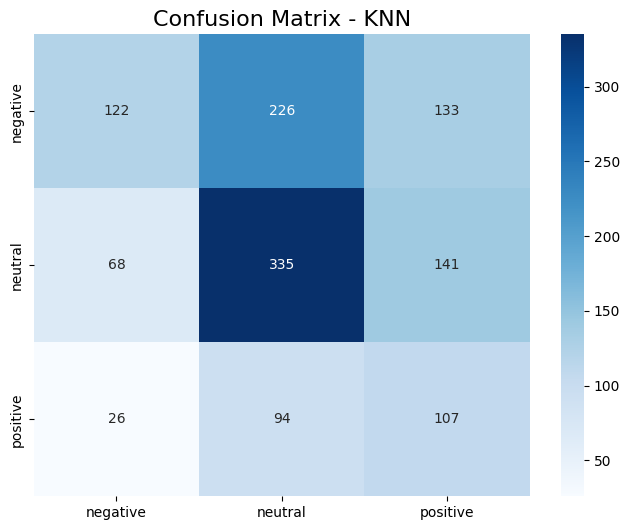

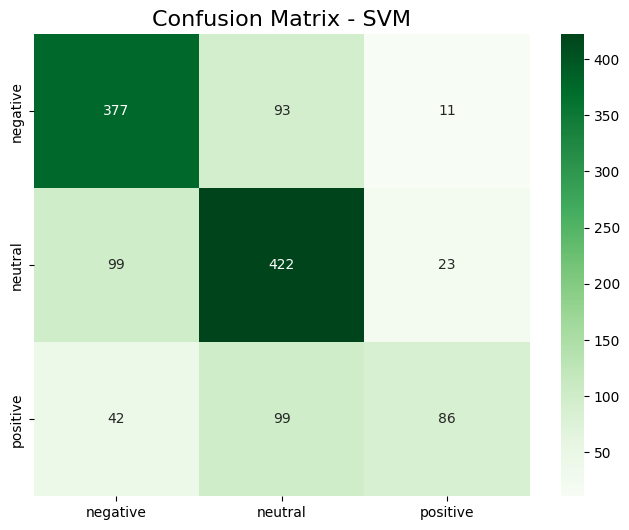

Mengurangi dimensi untuk visualisasi scatterplot...


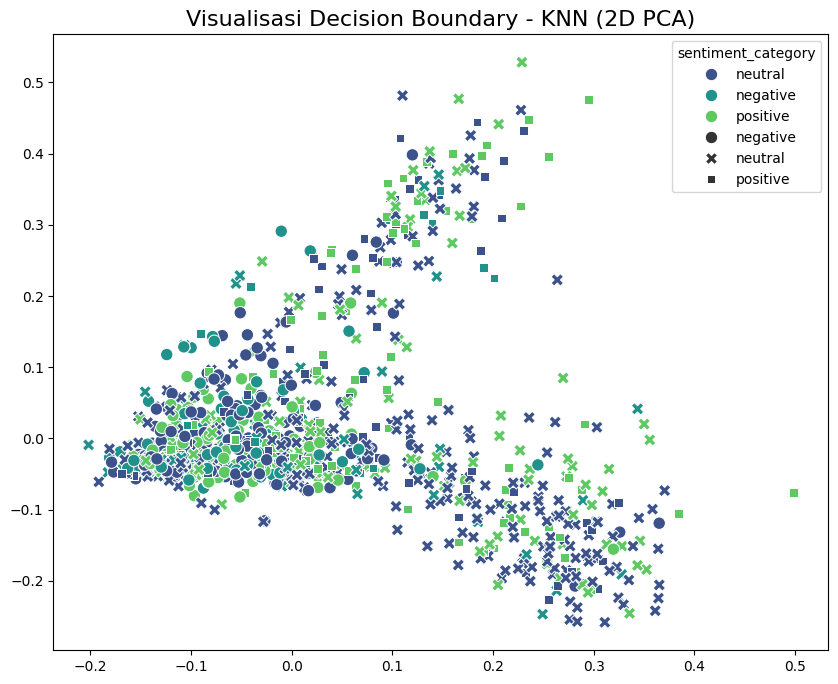

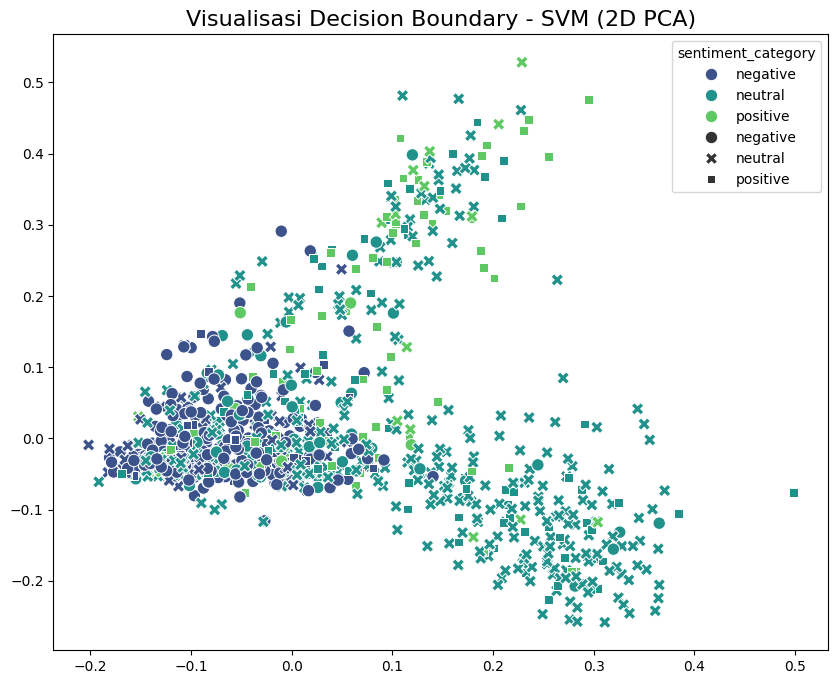

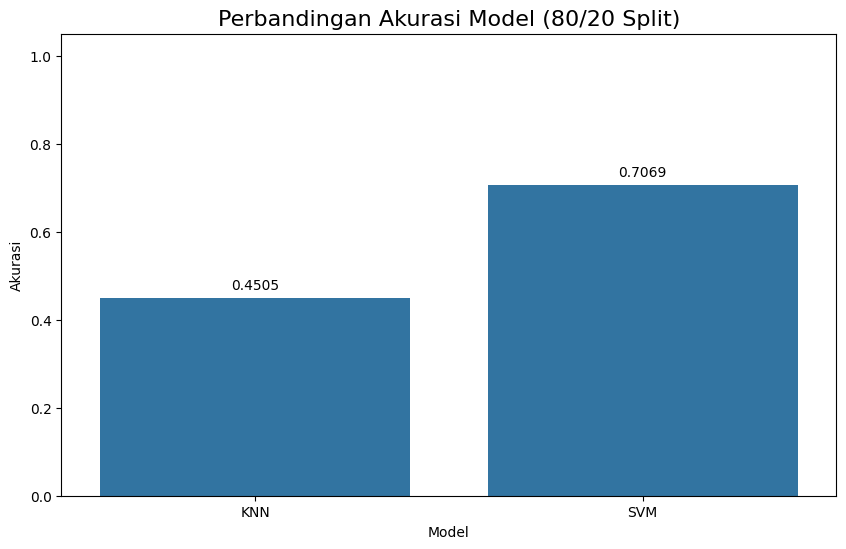


--- Membuat Word Cloud untuk Setiap Kategori Sentimen ---


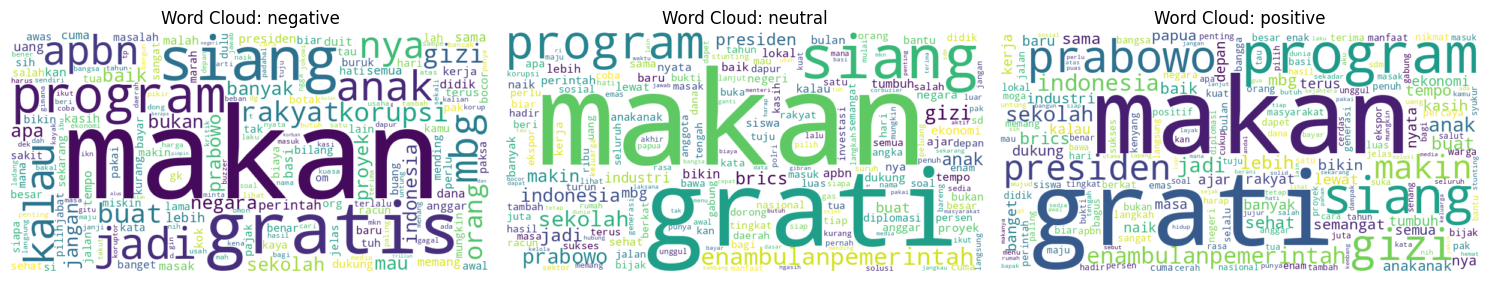

Proses evaluasi model lengkap selesai.


In [2]:
# ==============================================================================
# PART 5: EVALUASI MODEL LENGKAP (Akurasi, Presisi, Recall, F1, CV)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline # Diperlukan untuk Cross-Validation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

# --- Import for Word Cloud ---
from wordcloud import WordCloud

# --- Konfigurasi ---
HASIL_ANALISIS_FILE = 'final_sentiment_categorized.csv'
KOLOM_TEKS_BERSIH = 'text_cleaned'
KOLOM_TARGET = 'sentiment_category'

print("\n--- Memulai Part 5: Evaluasi Model Lengkap ---")

# --- 1. Muat dan Siapkan Data ---
try:
    df_model = pd.read_csv(HASIL_ANALISIS_FILE)
    df_model.dropna(subset=[KOLOM_TEKS_BERSIH, KOLOM_TARGET], inplace=True)
    print(f"Berhasil memuat data untuk pemodelan: {len(df_model)} baris.")
except FileNotFoundError:
    print(f"FATAL ERROR: File '{HASIL_ANALISIS_FILE}' tidak ditemukan.")
    exit()

X = df_model[KOLOM_TEKS_BERSIH]
y = df_model[KOLOM_TARGET]

# ==============================================================================
# A. EVALUASI DENGAN SINGLE SPLIT (80/20) UNTUK VISUALISASI
# ==============================================================================
print("\n--- A. Evaluasi dengan Single Split (80/20) ---")

# Bagi data: 80% data latih, 20% data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Ubah Teks menjadi Vektor Numerik dengan TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# --- Model K-Nearest Neighbors (KNN) ---
print("\n--- Melatih Model KNN (Single Split) ---")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_tfidf, y_train)
y_pred_knn = knn.predict(X_test_tfidf)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"Akurasi KNN: {accuracy_knn:.4f}")
print("Laporan Klasifikasi KNN (mencakup Presisi, Recall, F1-Score):")
print(classification_report(y_test, y_pred_knn))

# --- Model Support Vector Machine (SVM) ---
print("\n--- Melatih Model SVM (Single Split) ---")
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_tfidf, y_train)
y_pred_svm = svm.predict(X_test_tfidf)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Akurasi SVM: {accuracy_svm:.4f}")
print("Laporan Klasifikasi SVM (mencakup Presisi, Recall, F1-Score):")
print(classification_report(y_test, y_pred_svm))

# ==============================================================================
# B. EVALUASI ROBUST DENGAN K-FOLD CROSS-VALIDATION (CV)
# ==============================================================================
print("\n--- B. Evaluasi Robust dengan 5-Fold Cross-Validation ---")
# Untuk CV, kita perlu membuat 'pipeline' yang menggabungkan vectorizer dan classifier.
# Ini memastikan bahwa TF-IDF hanya di-fit pada data training di setiap 'fold'.
pipeline_knn = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', KNeighborsClassifier(n_neighbors=5))
])

pipeline_svm = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('clf', SVC(kernel='linear', random_state=42))
])

# Tentukan metrik yang akan diukur
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Jalankan Cross-Validation untuk KNN
print("\nMenjalankan 5-Fold CV untuk KNN...")
cv_results_knn = cross_validate(pipeline_knn, X, y, cv=5, scoring=scoring_metrics)

# Jalankan Cross-Validation untuk SVM
print("Menjalankan 5-Fold CV untuk SVM...")
cv_results_svm = cross_validate(pipeline_svm, X, y, cv=5, scoring=scoring_metrics)

# Tampilkan hasil rata-rata dari Cross-Validation
print("\n--- Hasil Rata-Rata Metriks dari 5-Fold Cross-Validation ---")
print("\nModel: K-Nearest Neighbors (KNN)")
print(f"   Rata-rata Akurasi     : {np.mean(cv_results_knn['test_accuracy']):.4f} (+/- {np.std(cv_results_knn['test_accuracy']):.4f})")
print(f"   Rata-rata Presisi (M): {np.mean(cv_results_knn['test_precision_macro']):.4f} (+/- {np.std(cv_results_knn['test_precision_macro']):.4f})")
print(f"   Rata-rata Recall (M) : {np.mean(cv_results_knn['test_recall_macro']):.4f} (+/- {np.std(cv_results_knn['test_recall_macro']):.4f})")
print(f"   Rata-rata F1-Score (M): {np.mean(cv_results_knn['test_f1_macro']):.4f} (+/- {np.std(cv_results_knn['test_f1_macro']):.4f})")

print("\nModel: Support Vector Machine (SVM)")
print(f"   Rata-rata Akurasi     : {np.mean(cv_results_svm['test_accuracy']):.4f} (+/- {np.std(cv_results_svm['test_accuracy']):.4f})")
print(f"   Rata-rata Presisi (M): {np.mean(cv_results_svm['test_precision_macro']):.4f} (+/- {np.std(cv_results_svm['test_precision_macro']):.4f})")
print(f"   Rata-rata Recall (M) : {np.mean(cv_results_svm['test_recall_macro']):.4f} (+/- {np.std(cv_results_svm['test_recall_macro']):.4f})")
print(f"   Rata-rata F1-Score (M): {np.mean(cv_results_svm['test_f1_macro']):.4f} (+/- {np.std(cv_results_svm['test_f1_macro']):.4f})")


# ==============================================================================
# C. VISUALISASI (BERDASARKAN SINGLE SPLIT)
# ==============================================================================
print("\n--- C. Membuat Visualisasi (berdasarkan single 80/20 split) ---")

# --- Visualisasi Confusion Matrix ---
# KNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title('Confusion Matrix - KNN', fontsize=16)
plt.show()

# SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', xticklabels=svm.classes_, yticklabels=svm.classes_)
plt.title('Confusion Matrix - SVM', fontsize=16)
plt.show()

# --- Visualisasi Scatterplot (PCA) ---
print("Mengurangi dimensi untuk visualisasi scatterplot...")
pca = PCA(n_components=2, random_state=42)
X_test_tfidf_dense = X_test_tfidf.toarray()
X_test_pca = pca.fit_transform(X_test_tfidf_dense)

# Scatterplot KNN
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_pred_knn, palette="viridis", style=y_test, s=80)
plt.title('Visualisasi Decision Boundary - KNN (2D PCA)', fontsize=16)
plt.show()

# Scatterplot SVM
plt.figure(figsize=(10, 8))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_pred_svm, palette="viridis", style=y_test, s=80)
plt.title('Visualisasi Decision Boundary - SVM (2D PCA)', fontsize=16)
plt.show()

# --- Visualisasi Perbandingan Akurasi (dari single split) ---
df_accuracy = pd.DataFrame({'Model': ['KNN', 'SVM'], 'Akurasi': [accuracy_knn, accuracy_svm]})
plt.figure(figsize=(10, 6))
splot = sns.barplot(x='Model', y='Akurasi', data=df_accuracy)
for p in splot.patches:
    splot.annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.title('Perbandingan Akurasi Model (80/20 Split)', fontsize=16)
plt.ylim(0, 1.05)
plt.show()

# --- Visualisasi Word Cloud ---
print("\n--- Membuat Word Cloud untuk Setiap Kategori Sentimen ---")
sentiment_categories = df_model[KOLOM_TARGET].unique()

plt.figure(figsize=(15, 10))
for i, category in enumerate(sentiment_categories):
    # Filter text for the current sentiment category
    text_for_wordcloud = " ".join(df_model[df_model[KOLOM_TARGET] == category][KOLOM_TEKS_BERSIH].dropna())

    if text_for_wordcloud: # Ensure there's text to generate a word cloud
        wordcloud = WordCloud(width=800, height=400, background_color='white', collocations=False).generate(text_for_wordcloud)

        plt.subplot(1, len(sentiment_categories), i + 1)
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.title(f'Word Cloud: {category}')
        plt.axis('off')
    else:
        print(f"Tidak ada teks yang cukup untuk membuat word cloud untuk kategori: {category}")

plt.tight_layout()
plt.show()


print("Proses evaluasi model lengkap selesai.")